**Setup**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import importlib.util
import sys

spec  = importlib.util.spec_from_file_location("utils", "/content/drive/MyDrive/ML_aircraft_recognition/utils.py")
utils = importlib.util.module_from_spec(spec)
sys.modules["utils"] = utils
spec.loader.exec_module(utils)

from utils import load_dataset, get_dataloaders, load_model, load_resnet

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


Using device: cuda


**Load data and models**

In [3]:
dataset = load_dataset()
train_loader, val_loader, test_loader, num_classes, train_size, val_size, test_size = get_dataloaders(dataset)

model_eff = load_model(num_classes, device)
model_res = load_resnet(num_classes, device)
print("Both models loaded!")

 100% |███████████████| 3334/3334 [1.9s elapsed, 0s remaining, 1.8K samples/s]      


INFO:eta.core.utils: 100% |███████████████| 3334/3334 [1.9s elapsed, 0s remaining, 1.8K samples/s]      


Loaded 3334 samples
Train: 2333 | Val: 500 | Test: 501 | Classes: 100
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 191MB/s]


Model loaded from /content/drive/MyDrive/ML_aircraft_recognition/best_model.pth
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 118MB/s]


ResNet loaded from /content/drive/MyDrive/ML_aircraft_recognition/best_resnet.pth
Both models loaded!


**Model evaluation**

In [4]:
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

def ensemble_evaluate(models, loader, device, num_classes):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            probs  = torch.zeros(imgs.size(0), num_classes).to(device)
            for model in models:
                model.eval()
                probs += torch.softmax(model(imgs), dim=1)
            all_preds.extend(probs.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

true_eff,      pred_eff      = evaluate(model_eff, test_loader, device)
true_res,      pred_res      = evaluate(model_res, test_loader, device)
true_ensemble, pred_ensemble = ensemble_evaluate([model_eff, model_res], test_loader, device, num_classes)

print(f"EfficientNetB0 accuracy : {(true_eff      == pred_eff).mean():.4f}")
print(f"ResNet50 accuracy       : {(true_res      == pred_res).mean():.4f}")
print(f"Ensemble accuracy       : {(true_ensemble == pred_ensemble).mean():.4f}")

EfficientNetB0 accuracy : 0.3553
ResNet50 accuracy       : 0.5549
Ensemble accuracy       : 0.5529


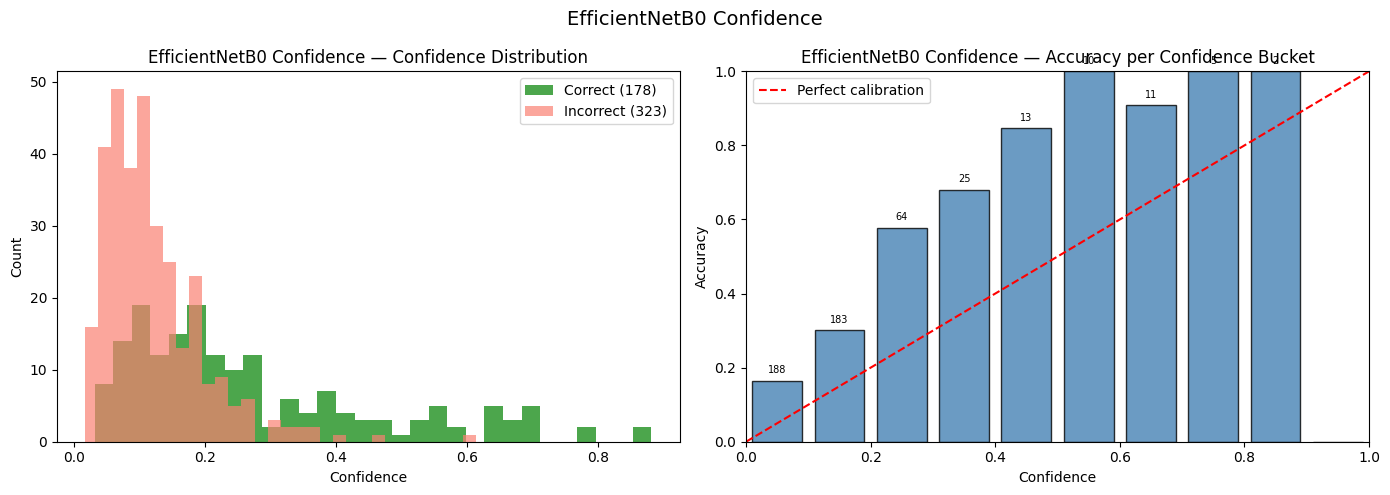

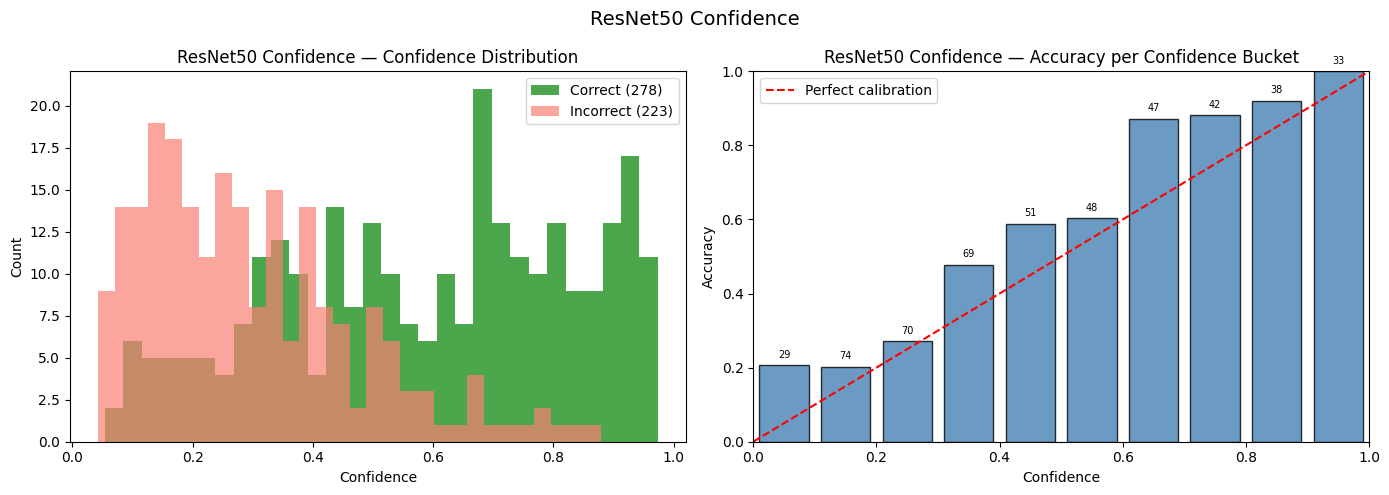

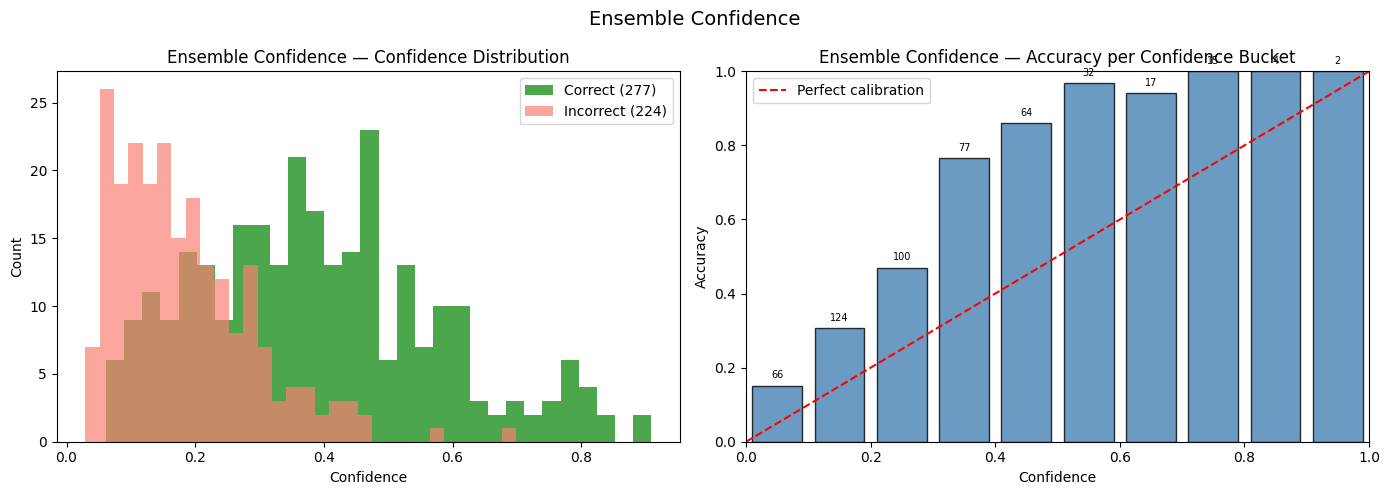

In [6]:
def plot_confidence_distribution(true_labels, pred_labels, models, loader, device, title):
    all_confidences = []
    all_correct     = []

    for model in models if isinstance(models, list) else [models]:
        model.eval()

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)

            if isinstance(models, list):
                probs = torch.zeros(imgs.size(0), num_classes).to(device)
                for model in models:
                    probs += torch.softmax(model(imgs), dim=1)
                probs /= len(models)
            else:
                probs = torch.softmax(models(imgs), dim=1)

            confidences, preds = probs.max(dim=1)
            correct = (preds.cpu() == labels)

            all_confidences.extend(confidences.cpu().numpy())
            all_correct.extend(correct.numpy())

    all_confidences = np.array(all_confidences)
    all_correct     = np.array(all_correct)

    correct_conf   = all_confidences[all_correct]
    incorrect_conf = all_confidences[~all_correct]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distribution of correct vs incorrect
    axes[0].hist(correct_conf,   bins=30, alpha=0.7, color="green",  label=f"Correct ({len(correct_conf)})")
    axes[0].hist(incorrect_conf, bins=30, alpha=0.7, color="salmon", label=f"Incorrect ({len(incorrect_conf)})")
    axes[0].set_title(f"{title} — Confidence Distribution")
    axes[0].set_xlabel("Confidence")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    # Accuracy per confidence bucket
    bins       = np.linspace(0, 1, 11)
    bin_accs   = []
    bin_counts = []
    bin_centers = (bins[:-1] + bins[1:]) / 2

    for low, high in zip(bins[:-1], bins[1:]):
        mask = (all_confidences >= low) & (all_confidences < high)
        if mask.sum() > 0:
            bin_accs.append(all_correct[mask].mean())
            bin_counts.append(mask.sum())
        else:
            bin_accs.append(0)
            bin_counts.append(0)

    bars = axes[1].bar(bin_centers, bin_accs, width=0.08,
                       color="steelblue", edgecolor="black", alpha=0.8)
    axes[1].plot([0, 1], [0, 1], "r--", label="Perfect calibration")
    axes[1].set_title(f"{title} — Accuracy per Confidence Bucket")
    axes[1].set_xlabel("Confidence")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].legend()

    for bar, count in zip(bars, bin_counts):
        if count > 0:
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                        str(count), ha="center", fontsize=7)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/ML_aircraft_recognition/{title.replace(' ', '_')}.png", dpi=150)
    plt.show()

plot_confidence_distribution(true_eff,      pred_eff,      model_eff,                  test_loader, device, "EfficientNetB0 Confidence")
plot_confidence_distribution(true_res,      pred_res,      model_res,                  test_loader, device, "ResNet50 Confidence")
plot_confidence_distribution(true_ensemble, pred_ensemble, [model_eff, model_res],     test_loader, device, "Ensemble Confidence")

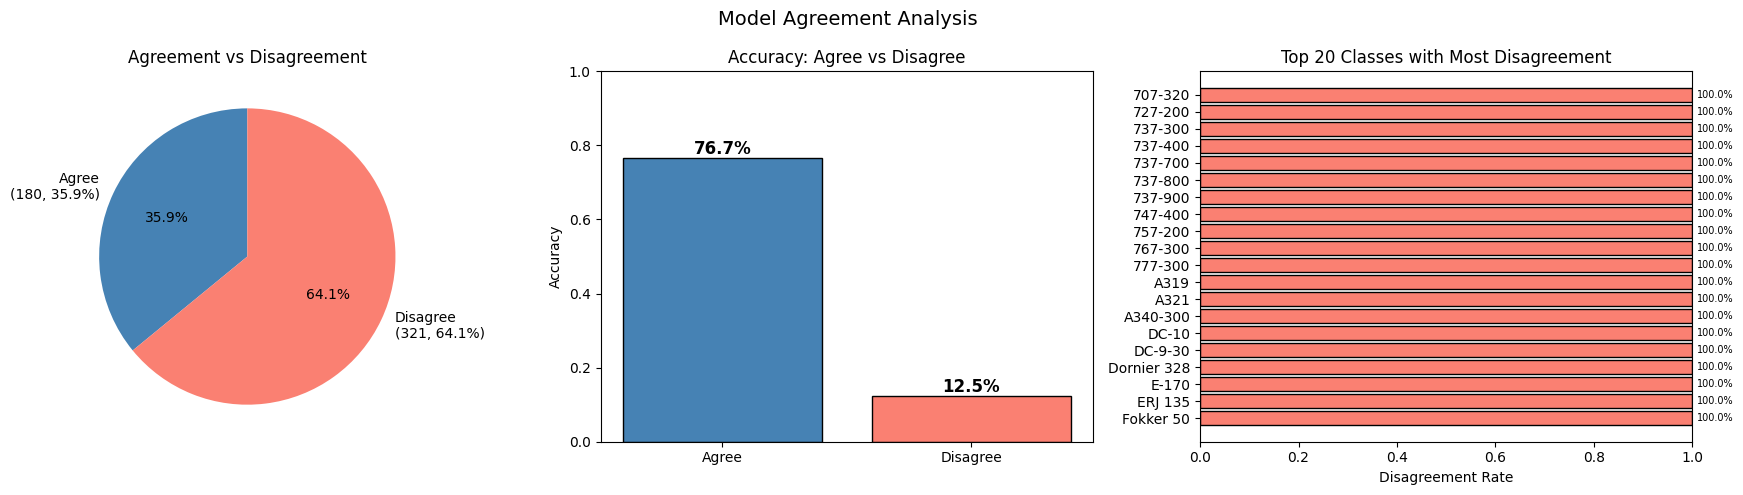

Total samples    : 501
Models agree     : 180 (35.9%) — Accuracy: 76.7%
Models disagree  : 321 (64.1%) — Accuracy: 12.5%


In [7]:
def plot_model_agreement(true_labels, pred_eff, pred_res, label_names, title="Model Agreement Analysis"):

    agree_mask    = pred_eff == pred_res
    disagree_mask = ~agree_mask

    agree_acc    = (true_labels[agree_mask]    == pred_eff[agree_mask]).mean()
    disagree_acc = (true_labels[disagree_mask] == pred_eff[disagree_mask]).mean()

    total       = len(true_labels)
    agree_count = agree_mask.sum()
    dis_count   = disagree_mask.sum()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Chart 1 — Agreement pie chart
    axes[0].pie(
        [agree_count, dis_count],
        labels=[f"Agree\n({agree_count}, {agree_count/total*100:.1f}%)",
                f"Disagree\n({dis_count}, {dis_count/total*100:.1f}%)"],
        colors=["steelblue", "salmon"],
        autopct="%1.1f%%",
        startangle=90
    )
    axes[0].set_title("Agreement vs Disagreement")

    # Chart 2 — Accuracy when agree vs disagree
    bars = axes[1].bar(
        ["Agree", "Disagree"],
        [agree_acc, disagree_acc],
        color=["steelblue", "salmon"],
        edgecolor="black"
    )
    axes[1].set_title("Accuracy: Agree vs Disagree")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1)
    for bar, acc in zip(bars, [agree_acc, disagree_acc]):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f"{acc*100:.1f}%", ha="center", fontsize=12, fontweight="bold")

    # Chart 3 — Per class disagreement rate
    disagree_per_class = []
    for i in range(len(label_names)):
        mask  = true_labels == i
        if mask.sum() > 0:
            rate = (pred_eff[mask] != pred_res[mask]).mean()
        else:
            rate = 0
        disagree_per_class.append(rate)

    sorted_data = sorted(zip(label_names, disagree_per_class), key=lambda x: x[1], reverse=True)
    top_labels, top_rates = zip(*sorted_data[:20])  # top 20 most disagreed classes

    axes[2].barh(top_labels[::-1], top_rates[::-1], color="salmon", edgecolor="black")
    axes[2].set_title("Top 20 Classes with Most Disagreement")
    axes[2].set_xlabel("Disagreement Rate")
    axes[2].set_xlim(0, 1)
    for i, rate in enumerate(top_rates[::-1]):
        axes[2].text(rate + 0.01, i, f"{rate*100:.1f}%", va="center", fontsize=7)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/ML_aircraft_recognition/{title.replace(' ', '_')}.png", dpi=150)
    plt.show()

    print(f"Total samples    : {total}")
    print(f"Models agree     : {agree_count} ({agree_count/total*100:.1f}%) — Accuracy: {agree_acc*100:.1f}%")
    print(f"Models disagree  : {dis_count} ({dis_count/total*100:.1f}%) — Accuracy: {disagree_acc*100:.1f}%")

plot_model_agreement(true_ensemble, pred_eff, pred_res, label_names)